In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ckay16_accident_detection_from_cctv_footage_path = kagglehub.dataset_download('ckay16/accident-detection-from-cctv-footage')
fahaddalwai_cctvfootagevideo_path = kagglehub.dataset_download('fahaddalwai/cctvfootagevideo')

print('Data source import complete.')


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import cv2
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
# Must be before any TF operation
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

tf.config.optimizer.set_jit(True)
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

c:\Users\dinesh\anaconda3\envs\aarthi312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
ckay16_accident_detection_from_cctv_footage_path

'C:\\Users\\dinesh\\.cache\\kagglehub\\datasets\\ckay16\\accident-detection-from-cctv-footage\\versions\\1'

# Setting up our Data  
Before we begin with creating and training our model, we will first set the size of the batches for our training, as well as the image height and width to set for our model

In [4]:
batch_size = 100
img_height = 250
img_width = 250

In [5]:
training_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f'{ckay16_accident_detection_from_cctv_footage_path}/data/train',
    seed=101,
    image_size= (img_height, img_width),
    batch_size=batch_size

)

testing_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f'{ckay16_accident_detection_from_cctv_footage_path}/data/test',
    seed=101,
    image_size= (img_height, img_width),
    batch_size=batch_size)

validation_ds =  tf.keras.preprocessing.image_dataset_from_directory(
    f'{ckay16_accident_detection_from_cctv_footage_path}/data/val',
    seed=101,
    image_size= (img_height, img_width),
    batch_size=batch_size)

Found 791 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Found 98 files belonging to 2 classes.


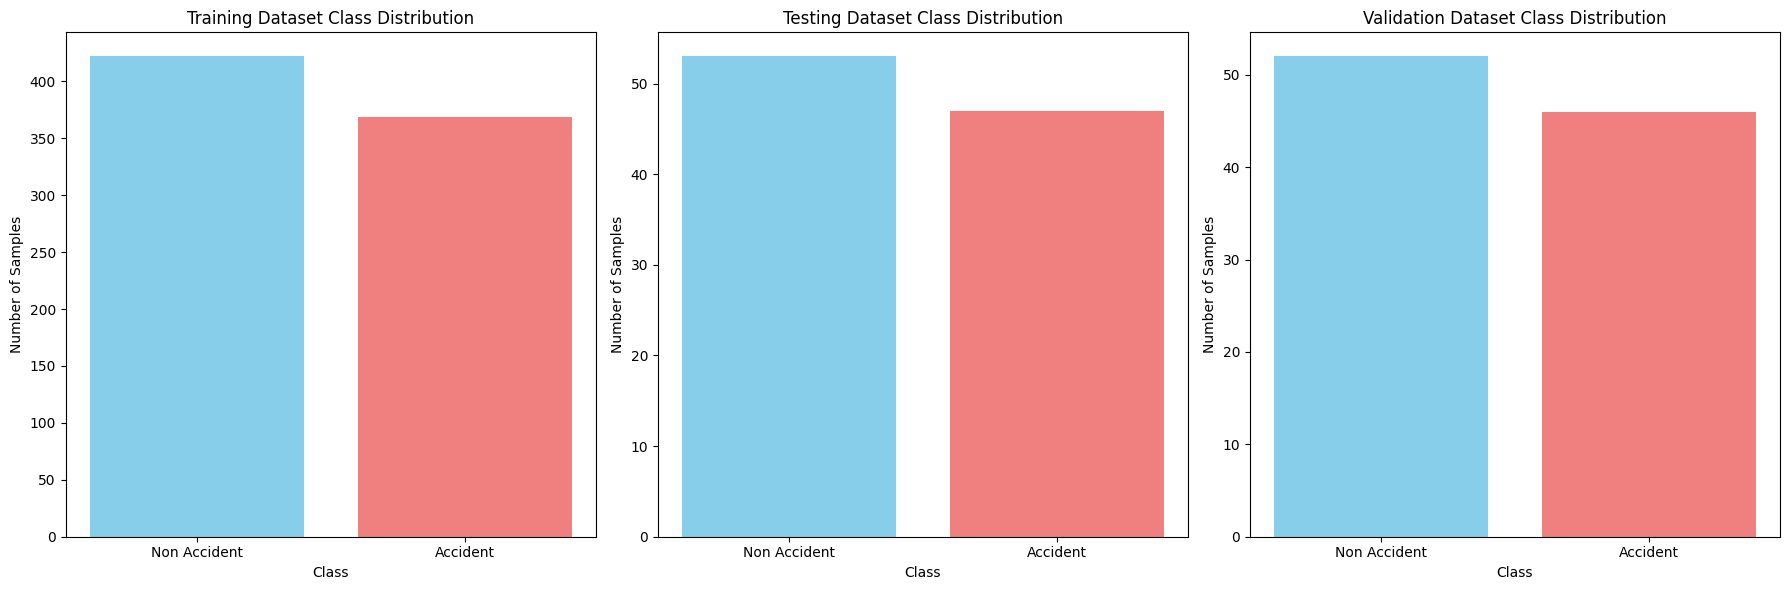

In [6]:
import collections

def get_class_distribution(dataset, class_names):
    labels = []
    for _, batch_labels in dataset:
        labels.extend(batch_labels.numpy())
    label_counts = collections.Counter(labels)
    return {class_names[k]: v for k, v in label_counts.items()}

class_names = training_ds.class_names

training_dist = get_class_distribution(training_ds, class_names)
testing_dist = get_class_distribution(testing_ds, class_names)
validation_dist = get_class_distribution(validation_ds, class_names)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Training dataset distribution
axes[0].bar(training_dist.keys(), training_dist.values(), color=['skyblue', 'lightcoral'])
axes[0].set_title('Training Dataset Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')

# Testing dataset distribution
axes[1].bar(testing_dist.keys(), testing_dist.values(), color=['skyblue', 'lightcoral'])
axes[1].set_title('Testing Dataset Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Samples')

# Validation dataset distribution
axes[2].bar(validation_dist.keys(), validation_dist.values(), color=['skyblue', 'lightcoral'])
axes[2].set_title('Validation Dataset Class Distribution')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

In [7]:
# import tensorflow as tf

# # Use all CPU cores
# tf.config.threading.set_intra_op_parallelism_threads(0)
# tf.config.threading.set_inter_op_parallelism_threads(0)

# # Enable XLA optimization
# tf.config.optimizer.set_jit(True)

In [8]:
## Configuring dataset for performance
AUTOTUNE = tf.data.experimental.AUTOTUNE
training_ds = training_ds.cache().prefetch(buffer_size=AUTOTUNE)
testing_ds = testing_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Defining our Pre-Trained Model  

In [9]:
img_shape = (img_height, img_width, 3)

base_model = tf.keras.applications.MobileNetV2(input_shape=img_shape,
                                               include_top=False,
                                               weights='imagenet')

base_model.trainable = False

C:\Users\dinesh\AppData\Local\Temp\ipykernel_22608\451698701.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=img_shape,


# Creating Final Model  


In [10]:
MobileNet = tf.keras.Sequential([
    base_model,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.Conv2D(128, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(len(class_names), activation= 'softmax')
])

In [11]:
from tensorflow.keras.optimizers import Adam

# Define a custom learning rate
learning_rate = 0.001  # You can adjust this value as needed

# Compile the model with the custom optimizer, instantiating Adam directly
MobileNet.compile(optimizer=Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=15,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity.
)

In [13]:
epochs = 30

In [14]:
# MobileNet.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
MobileNet_history = MobileNet.fit(training_ds, validation_data = validation_ds, epochs = epochs, callbacks=[early_stopping_callback])

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 818ms/step - accuracy: 0.5499 - loss: 0.7626 - val_accuracy: 0.6633 - val_loss: 0.6130
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 580ms/step - accuracy: 0.7307 - loss: 0.5395 - val_accuracy: 0.7653 - val_loss: 0.5346
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 527ms/step - accuracy: 0.8508 - loss: 0.3682 - val_accuracy: 0.8061 - val_loss: 0.4102
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 514ms/step - accuracy: 0.9001 - loss: 0.2412 - val_accuracy: 0.8163 - val_loss: 0.3992
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 633ms/step - accuracy: 0.9482 - loss: 0.1494 - val_accuracy: 0.8878 - val_loss: 0.2359
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 633ms/step - accuracy: 0.9646 - loss: 0.0999 - val_accuracy: 0.8878 - val_loss: 0.2556
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 633ms/step - accuracy: 0.9709 - loss: 0.0787 - val_accuracy: 0.8673 - val_loss: 0.4066
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 631ms/step - accuracy: 0.9709 - loss: 0.0696 - val_accuracy: 0.8061 - val_loss

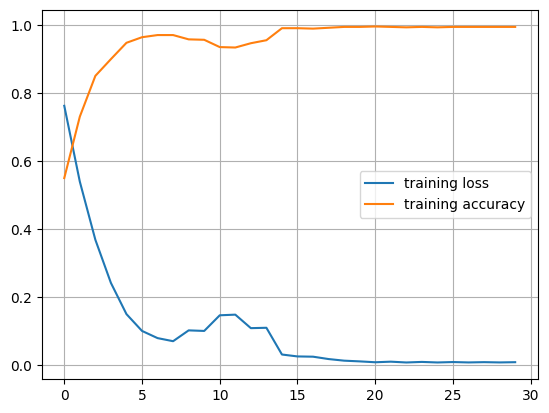

In [16]:
plt.plot(MobileNet_history.history['loss'], label = 'training loss')
plt.plot(MobileNet_history.history['accuracy'], label = 'training accuracy')
plt.grid(True)
plt.legend()

In [17]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the testing dataset
true_labels = np.concatenate([y for x, y in testing_ds], axis=0)

# Get predictions from the model on the testing dataset
predictions = MobileNet.predict(testing_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Generate and print the classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step
              precision    recall  f1-score   support

    Accident       0.95      0.83      0.89        47
Non Accident       0.86      0.96      0.91        53

    accuracy                           0.90       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.90      0.90       100



The function below looks a bit complicated, but is a simple helper function which shows the image, the predicted class and the actual class for each image in the test dataset. Run it and have a look at how accurate the model seems and where it seems to be struggling.

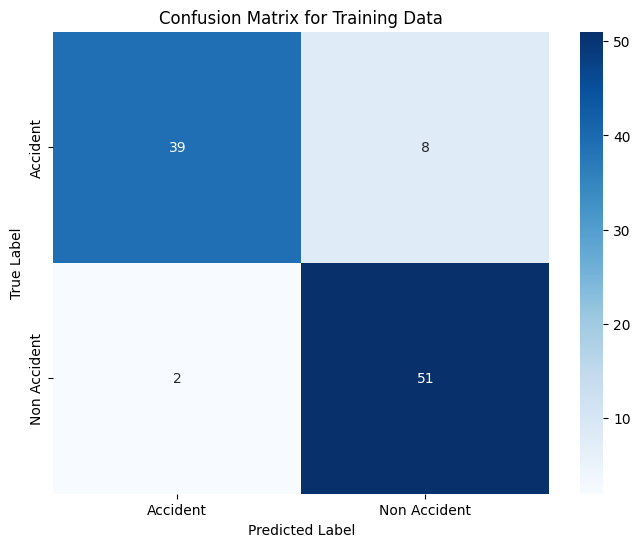

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Training Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#ResNet50 Model

In [19]:
img_shape = (img_height, img_width, 3)

base_model = tf.keras.applications.ResNet50(
    input_shape=img_shape,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

ResNet = tf.keras.Sequential([
    base_model,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.Conv2D(128, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(len(class_names), activation= 'softmax')
])

In [20]:
from tensorflow.keras.optimizers import Adam

learning_rate = 0.001

ResNet.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
ResNet_history = ResNet.fit(
    training_ds,
    validation_data=validation_ds,
    epochs=epochs,
    callbacks=[early_stopping_callback]
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5474 - loss: 1.4502 - val_accuracy: 0.5714 - val_loss: 0.6374
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7750 - loss: 0.4636 - val_accuracy: 0.8673 - val_loss: 0.3460
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9153 - loss: 0.2281 - val_accuracy: 0.9082 - val_loss: 0.2326
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9583 - loss: 0.1245 - val_accuracy: 0.8878 - val_loss: 0.2551
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9659 - loss: 0.0868 - val_accuracy: 0.8776 - val_loss: 0.2258
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9722 - loss: 0.0798 - val_accuracy: 0.8980 - val_loss: 0.2105
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9810 - loss: 0.0463 - val_accuracy: 0.9184 - val_loss: 0.1599
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9886 - loss: 0.0310 - val_accuracy: 0.8878 - val_loss: 0.2133
Epoch 9/

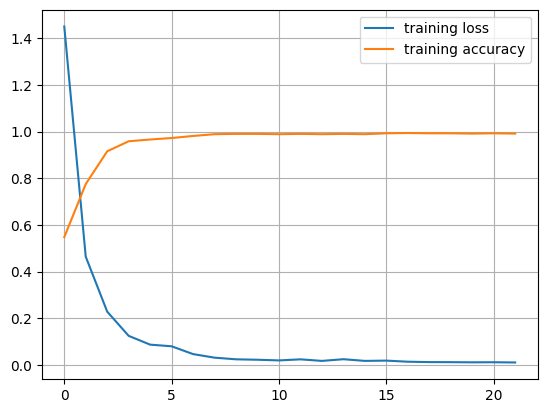

In [22]:
plt.plot(ResNet_history.history['loss'], label='training loss')
plt.plot(ResNet_history.history['accuracy'], label='training accuracy')
plt.grid(True)
plt.legend()

In [23]:
from sklearn.metrics import classification_report
import numpy as np

true_labels = np.concatenate([y for x, y in testing_ds], axis=0)

predictions = ResNet.predict(testing_ds)
predicted_labels = np.argmax(predictions, axis=1)

report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

    Accident       0.98      0.96      0.97        47
Non Accident       0.96      0.98      0.97        53

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



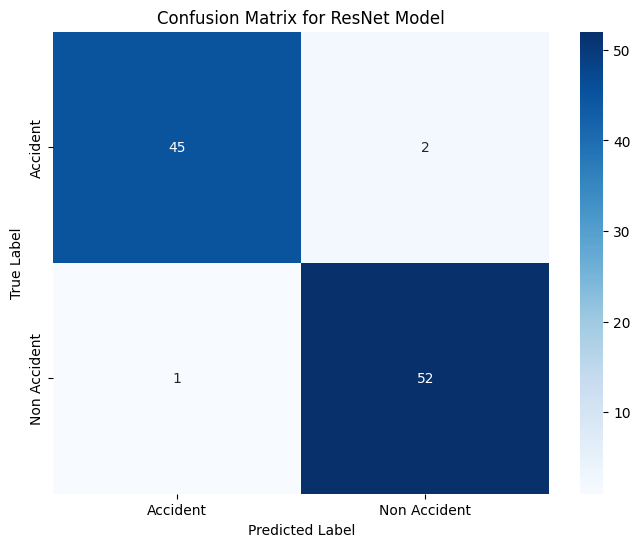

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix for ResNet Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#InceptionV3

In [28]:
img_shape = (img_height, img_width, 3)

base_model = tf.keras.applications.InceptionV3(
    input_shape=img_shape,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# Inception = tf.keras.Sequential([
#     base_model,
#     layers.Conv2D(32, 3, activation='relu'),
#     layers.Conv2D(64, 3, activation='relu'),
#     layers.Conv2D(128, 3, activation='relu'),
#     layers.Flatten(),
#     layers.Dense(len(class_names), activation= 'softmax')
# ])


Inception = tf.keras.Sequential([
    base_model,
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(class_names), activation='softmax')
])

In [29]:
from tensorflow.keras.optimizers import Adam

learning_rate = 0.001

Inception.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
Inception_history = Inception.fit(
    training_ds,
    validation_data=validation_ds,
    epochs=epochs,
    # callbacks=[early_stopping_callback]
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 727ms/step - accuracy: 0.5120 - loss: 4.3003 - val_accuracy: 0.5306 - val_loss: 2.2620
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5411 - loss: 1.9854 - val_accuracy: 0.4796 - val_loss: 1.2438
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5638 - loss: 1.0537 - val_accuracy: 0.5816 - val_loss: 0.7444
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6144 - loss: 0.6923 - val_accuracy: 0.6327 - val_loss: 0.6656
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6068 - loss: 0.6584 - val_accuracy: 0.7245 - val_loss: 0.6044
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6953 - loss: 0.5838 - val_accuracy: 0.7653 - val_loss: 0.5351
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7320 - loss: 0.5421 - val_accuracy: 0.7449 - val_loss: 0.4841
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7712 - loss: 0.5002 - val_accuracy: 0.8265 - val_loss: 0.4559
Epoch 

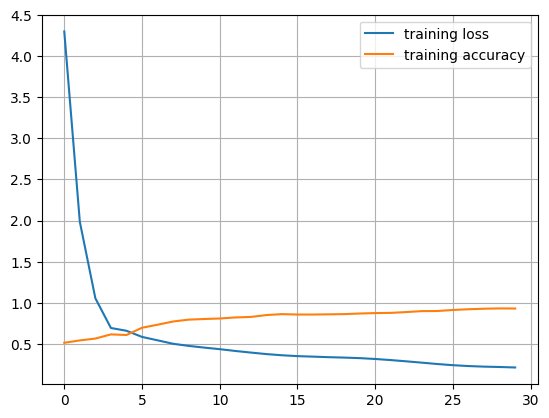

In [32]:
plt.plot(Inception_history.history['loss'], label='training loss')
plt.plot(Inception_history.history['accuracy'], label='training accuracy')
plt.grid(True)
plt.legend()

In [33]:
true_labels = np.concatenate([y for x, y in testing_ds], axis=0)

predictions = Inception.predict(testing_ds)
predicted_labels = np.argmax(predictions, axis=1)

report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

    Accident       0.83      0.94      0.88        47
Non Accident       0.94      0.83      0.88        53

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.88      0.88       100



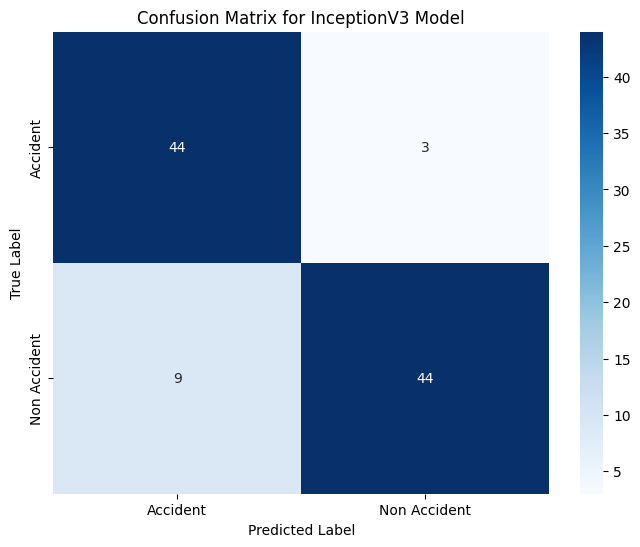

In [34]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix for InceptionV3 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
MobileNet.save("MobileNet_model_accident.keras")
ResNet.save("ResNet_model_accident.keras")
Inception.save("InceptionV3_model_accident.keras")

**Reasoning**:
Gradio has been successfully installed. The next step is to define a prediction function that takes an image, preprocesses it for the model, makes a prediction, and returns the classified label and confidence scores. This function will then be used to create the Gradio interface.



In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

# Define the prediction function
def predict_image(image):
    # Preprocess the image
    img = Image.fromarray(image.astype('uint8'), 'RGB')
    img = img.resize((img_height, img_width))
    # batch_size = 100
    # img_height = 250
    # img_width = 250
    img_array = np.array(img) / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make prediction
    predictions = loaded_model.predict(img_array)
    predicted_class_idx = np.argmax(predictions)
    predicted_class_label = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100

    # Return a dictionary with class probabilities for Gradio
    return {class_names[i]: float(predictions[0][i]) for i in range(len(class_names))}

**Reasoning**:
The `predict_image` function has been defined. Now, I need to create the Gradio interface using this function. The interface will take an image as input and display the predicted class probabilities as output.



In [ ]:
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(),
    title="Accident Detection from CCTV Footage",
    description="Upload an image to predict if it contains an 'Accident' or 'Non Accident'."
)

iface.launch()